# Prepocessing the data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cols="""duration,
protocol_type,
service,
flag,
src_bytes,
dst_bytes,
land,
wrong_fragment,
urgent,
hot,
num_failed_logins,
logged_in,
num_compromised,
root_shell,
su_attempted,
num_root,
num_file_creations,
num_shells,
num_access_files,
num_outbound_cmds,
is_host_login,
is_guest_login,
count,
srv_count,
serror_rate,
srv_serror_rate,
rerror_rate,
srv_rerror_rate,
same_srv_rate,
diff_srv_rate,
srv_diff_host_rate,
dst_host_count,
dst_host_srv_count,
dst_host_same_srv_rate,
dst_host_diff_srv_rate,
dst_host_same_src_port_rate,
dst_host_srv_diff_host_rate,
dst_host_serror_rate,
dst_host_srv_serror_rate,
dst_host_rerror_rate,
dst_host_srv_rerror_rate"""

columns=[]
for c in cols.split(','):
    if(c.strip()):
       columns.append(c.strip())

columns.append('target')
#print(columns)
print(len(columns))

42


In [3]:
attacks_types = {
    'normal': 'normal',
'back': 'dos',
'buffer_overflow': 'u2r',
'ftp_write': 'r2l',
'guess_passwd': 'r2l',
'imap': 'r2l',
'ipsweep': 'probe',
'land': 'dos',
'loadmodule': 'u2r',
'multihop': 'r2l',
'neptune': 'dos',
'nmap': 'probe',
'perl': 'u2r',
'phf': 'r2l',
'pod': 'dos',
'portsweep': 'probe',
'rootkit': 'u2r',
'satan': 'probe',
'smurf': 'dos',
'spy': 'r2l',
'teardrop': 'dos',
'warezclient': 'r2l',
'warezmaster': 'r2l',
}

In [4]:
path = "../input/kdd-cup-1999-data/kddcup.data_10_percent.gz"
df = pd.read_csv(path,names=columns)

#Adding Attack Type column
df['Attack Type'] = df.target.apply(lambda r:attacks_types[r[:-1]])

df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target,Attack Type
0,0,tcp,http,SF,181,5450,0,0,0,0,...,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.,normal
1,0,tcp,http,SF,239,486,0,0,0,0,...,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.,normal
2,0,tcp,http,SF,235,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,normal
3,0,tcp,http,SF,219,1337,0,0,0,0,...,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.,normal
4,0,tcp,http,SF,217,2032,0,0,0,0,...,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.,normal


In [5]:
df['Attack Type'].value_counts()

dos       391458
normal     97278
probe       4107
r2l         1126
u2r           52
Name: Attack Type, dtype: int64

# Visualizing the data

In [6]:
#Visualization
def bar_graph(feature):
    df[feature].value_counts().plot(kind="bar")

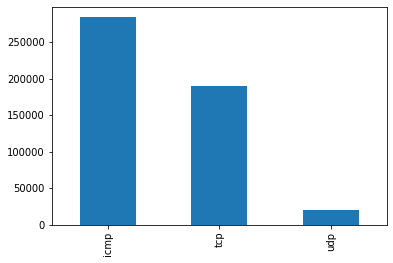

In [7]:
bar_graph('protocol_type')

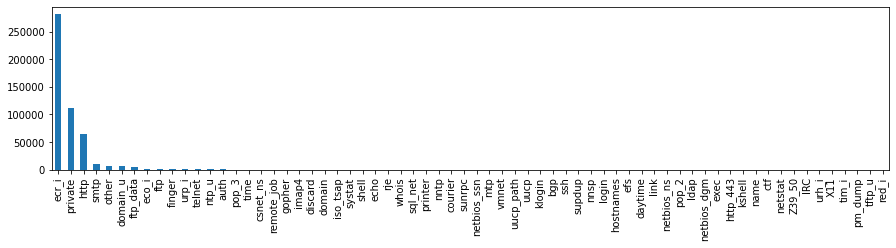

In [8]:
plt.figure(figsize=(15,3))
bar_graph('service')

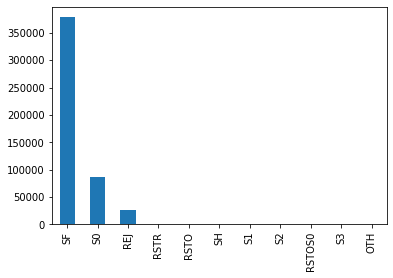

In [9]:
bar_graph('flag')

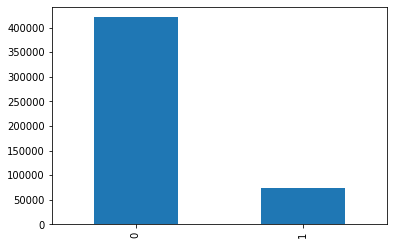

In [10]:
bar_graph('logged_in')

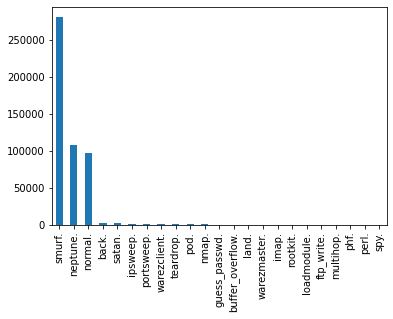

In [11]:
bar_graph('target')

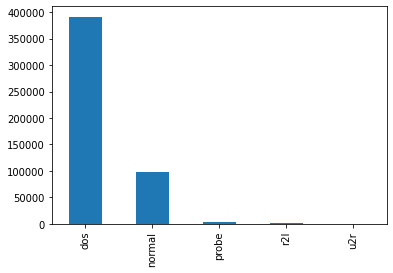

In [12]:
bar_graph('Attack Type')

In [13]:
df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'target', 'Attack Type'],
      dtype='object')

# Removing highly correlated columns

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: FutureWarning: In a future version of pandas all arguments of DataFrame.dropna will be keyword-only
  """Entry point for launching an IPython kernel.


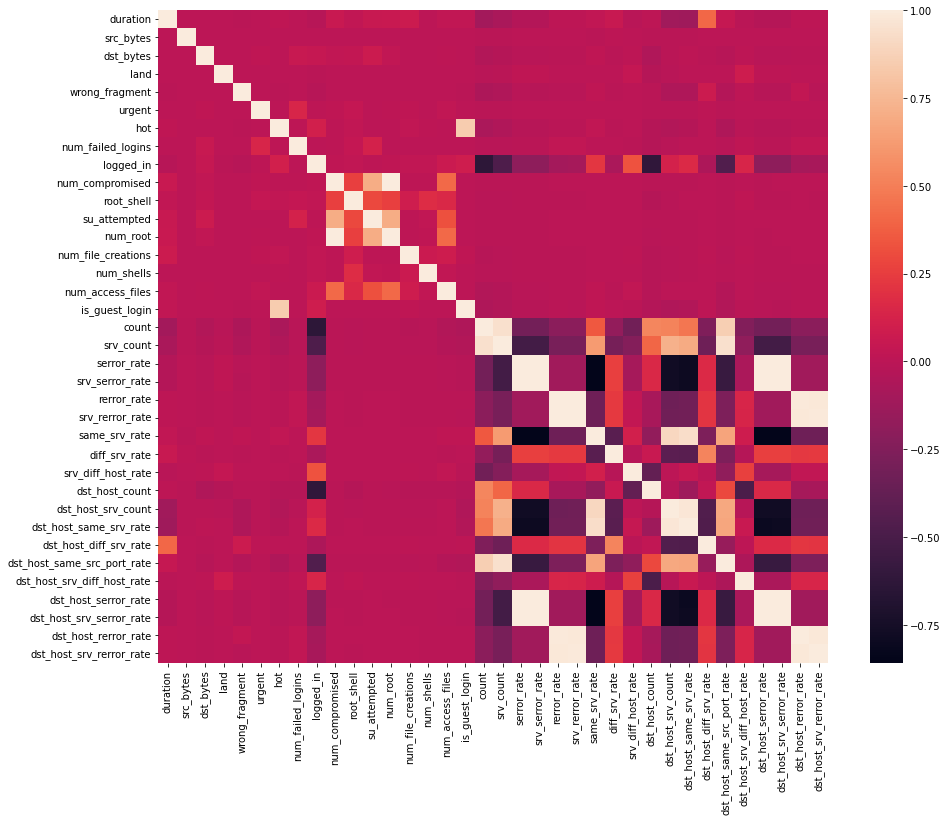

In [14]:
df = df.dropna('columns')# drop columns with NaN

df = df[[col for col in df if df[col].nunique() > 1]]# keep columns where there are more than 1 unique values

corr = df.corr()

plt.figure(figsize=(15,12))

sns.heatmap(corr)

plt.show()

In [15]:
#This variable is highly correlated with num_compromised and should be ignored for analysis.
#(Correlation = 0.9938277978738366)
df.drop('num_root',axis = 1,inplace = True)

#This variable is highly correlated with serror_rate and should be ignored for analysis.
#(Correlation = 0.9983615072725952)
df.drop('srv_serror_rate',axis = 1,inplace = True)

#This variable is highly correlated with rerror_rate and should be ignored for analysis.
#(Correlation = 0.9947309539817937)
df.drop('srv_rerror_rate',axis = 1, inplace=True)

#This variable is highly correlated with srv_serror_rate and should be ignored for analysis.
#(Correlation = 0.9993041091850098)
df.drop('dst_host_srv_serror_rate',axis = 1, inplace=True)

#This variable is highly correlated with rerror_rate and should be ignored for analysis.
#(Correlation = 0.9869947924956001)
df.drop('dst_host_serror_rate',axis = 1, inplace=True)

#This variable is highly correlated with srv_rerror_rate and should be ignored for analysis.
#(Correlation = 0.9821663427308375)
df.drop('dst_host_rerror_rate',axis = 1, inplace=True)

#This variable is highly correlated with rerror_rate and should be ignored for analysis.
#(Correlation = 0.9851995540751249)
df.drop('dst_host_srv_rerror_rate',axis = 1, inplace=True)

#This variable is highly correlated with dst_host_srv_count and should be ignored for analysis.
#(Correlation = 0.9736854572953938)
df.drop('dst_host_same_srv_rate',axis = 1, inplace=True)

In [16]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,target,Attack Type
0,0,tcp,http,SF,181,5450,0,0,0,0,...,1.0,0.0,0.0,9,9,0.0,0.11,0.0,normal.,normal
1,0,tcp,http,SF,239,486,0,0,0,0,...,1.0,0.0,0.0,19,19,0.0,0.05,0.0,normal.,normal
2,0,tcp,http,SF,235,1337,0,0,0,0,...,1.0,0.0,0.0,29,29,0.0,0.03,0.0,normal.,normal
3,0,tcp,http,SF,219,1337,0,0,0,0,...,1.0,0.0,0.0,39,39,0.0,0.03,0.0,normal.,normal
4,0,tcp,http,SF,217,2032,0,0,0,0,...,1.0,0.0,0.0,49,49,0.0,0.02,0.0,normal.,normal


# Label encoding the features

In [17]:
#protocol_type feature mapping
pmap = {'icmp':0,'tcp':1,'udp':2}
df['protocol_type'] = df['protocol_type'].map(pmap)

In [18]:
#flag feature mapping
fmap = {'SF':0,'S0':1,'REJ':2,'RSTR':3,'RSTO':4,'SH':5 ,'S1':6 ,'S2':7,'RSTOS0':8,'S3':9 ,'OTH':10}
df['flag'] = df['flag'].map(fmap)

In [19]:
#attack type feature mapping
amap = {'dos':0,'normal':1,'probe':2,'r2l':3,'u2r':4}
df['Attack Type'] = df['Attack Type'].map(amap)

In [20]:
df.drop('service',axis = 1,inplace= True)

# Building and training a Neural Network

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

In [22]:
import tensorflow as tf
from keras.models import Sequential, Model
from keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, Input, Concatenate, Add

In [23]:
df = df.drop(['target',], axis=1)
print(df.shape)

# Target variable and train set
Y = df[['Attack Type']]
X = df.drop(['Attack Type',], axis=1)

sc = MinMaxScaler()
X = sc.fit_transform(X)

# Split test and train data 
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=42)
print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(494021, 31)
(330994, 30) (163027, 30)
(330994, 1) (163027, 1)


In [24]:
df.to_csv("ids.csv", index=False)

In [25]:
pd.read_csv("ids.csv")

,duration,protocol_type,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,...,rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,Attack Type
0,0,1,0,181,5450,0,0,0,0,0,...,0.0,1.0,0.0,0.00,9,9,0.0,0.11,0.00,1
1,0,1,0,239,486,0,0,0,0,0,...,0.0,1.0,0.0,0.00,19,19,0.0,0.05,0.00,1
2,0,1,0,235,1337,0,0,0,0,0,...,0.0,1.0,0.0,0.00,29,29,0.0,0.03,0.00,1
3,0,1,0,219,1337,0,0,0,0,0,...,0.0,1.0,0.0,0.00,39,39,0.0,0.03,0.00,1
4,0,1,0,217,2032,0,0,0,0,0,...,0.0,1.0,0.0,0.00,49,49,0.0,0.02,0.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494016,0,1,0,310,1881,0,0,0,0,0,...,0.0,1.0,0.0,0.40,86,255,0.0,0.01,0.05,1
494017,0,1,0,282,2286,0,0,0,0,0,...,0.0,1.0,0.0,0.00,6,255,0.0,0.17,0.05,1
494018,0,1,0,203,1200,0,0,0,0,0,...,0.0,1.0,0.0,0.17,16,255,0.0,0.06,0.05,1
494019,0,1,0,291,1200,0,0,0,0,0,...,0.0,1.0,0.0,0.17,26,255,0.0,0.04,0.05,1


## Shallow Neural Network

In [26]:
shallow_model = Sequential([
    Dense(1024, input_dim=30, activation='relu'),
    Dropout(0.01),
    Dense(5, activation='softmax')
])

In [27]:
shallow_model.compile(loss ='sparse_categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

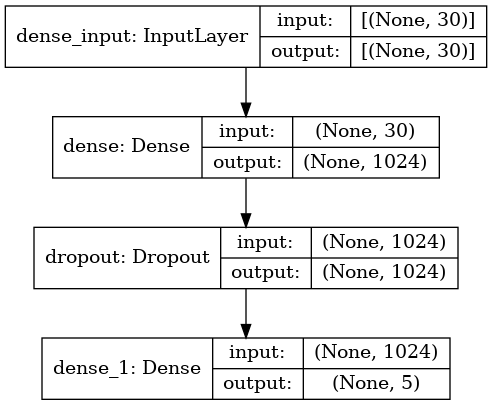

In [28]:
tf.keras.utils.plot_model(shallow_model, to_file="shallow_model.png", show_shapes=True)

In [29]:
shallow_model.fit(X_train, Y_train.values.ravel(), epochs=10, batch_size=32)

Epoch 1/10
10344/10344 [==============================] - 34s 3ms/step - loss: 0.0136 - accuracy: 0.9964
Epoch 2/10
10344/10344 [==============================] - 37s 4ms/step - loss: 0.0046 - accuracy: 0.9987
Epoch 3/10
10344/10344 [==============================] - 31s 3ms/step - loss: 0.0041 - accuracy: 0.9989
Epoch 4/10
10344/10344 [==============================] - 28s 3ms/step - loss: 0.0036 - accuracy: 0.9990
Epoch 5/10
10344/10344 [==============================] - 29s 3ms/step - loss: 0.0034 - accuracy: 0.9990
Epoch 6/10
10344/10344 [==============================] - 30s 3ms/step - loss: 0.0035 - accuracy: 0.9991
Epoch 7/10
10344/10344 [==============================] - 29s 3ms/step - loss: 0.0033 - accuracy: 0.9992
Epoch 8/10
10344/10344 [==============================] - 27s 3ms/step - loss: 0.0033 - accuracy: 0.9992
Epoch 9/10
10344/10344 [==============================] - 31s 3ms/step - loss: 0.0032 - accuracy: 0.9992
Epoch 10/10
10344/10344 [==============================

## Deep Neural Network

In [30]:
deep_model = Sequential([
    Dense(1024, input_dim=30, activation='relu'),
    Dropout(0.01),
    Dense(768, activation='relu'),
    Dropout(0.01),
    Dense(512, activation='relu'),
    Dropout(0.01),
    Dense(256, activation='relu'),
    Dropout(0.01),
    Dense(128, activation='relu'),
    Dropout(0.01),
    Dense(5, activation='softmax')
])

In [31]:
deep_model.compile(loss ='sparse_categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

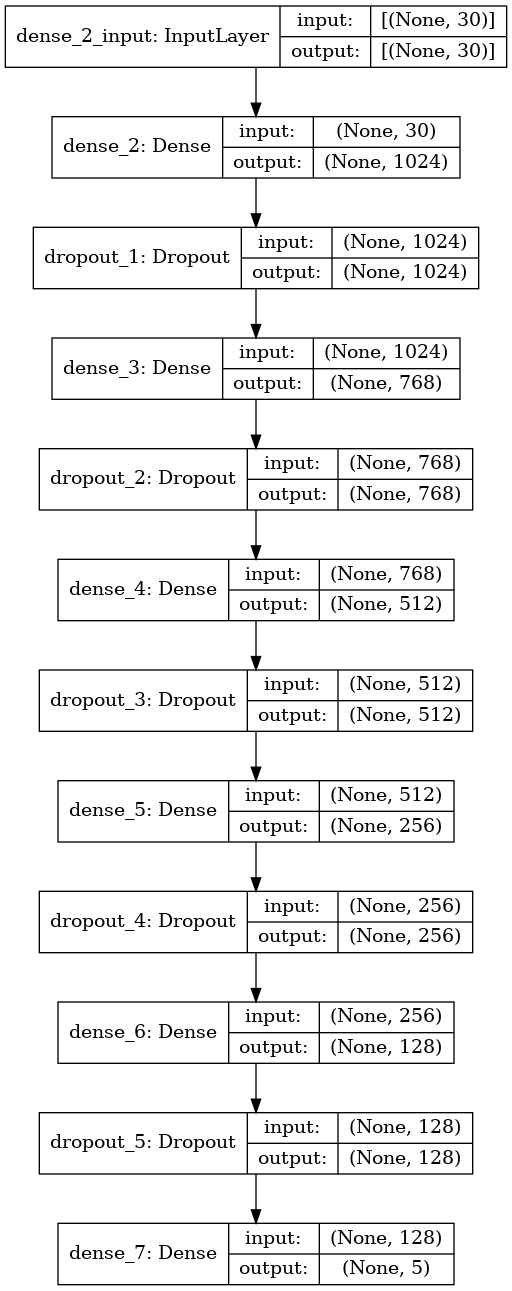

In [32]:
tf.keras.utils.plot_model(deep_model, to_file="deep_model.png", show_shapes=True)

In [33]:
deep_model.fit(X_train, Y_train.values.ravel(), epochs=10, batch_size=32)

Epoch 1/10
10344/10344 [==============================] - 115s 11ms/step - loss: 0.0157 - accuracy: 0.9964
Epoch 2/10
10344/10344 [==============================] - 112s 11ms/step - loss: 0.0088 - accuracy: 0.9981
Epoch 3/10
10344/10344 [==============================] - 108s 10ms/step - loss: 0.0074 - accuracy: 0.9984
Epoch 4/10
10344/10344 [==============================] - 112s 11ms/step - loss: 0.0062 - accuracy: 0.9986
Epoch 5/10
10344/10344 [==============================] - 106s 10ms/step - loss: 0.0059 - accuracy: 0.9987
Epoch 6/10
10344/10344 [==============================] - 108s 10ms/step - loss: 0.0058 - accuracy: 0.9987
Epoch 7/10
10344/10344 [==============================] - 113s 11ms/step - loss: 0.0066 - accuracy: 0.9988
Epoch 8/10
10344/10344 [==============================] - 119s 12ms/step - loss: 0.0060 - accuracy: 0.9988
Epoch 9/10
10344/10344 [==============================] - 130s 13ms/step - loss: 0.0057 - accuracy: 0.9989
Epoch 10/10
10344/10344 [============

## Convolutional Neural Network

In [34]:
# cnn_model = Sequential([
#     Conv1D(64, 3, padding="same", activation="relu", input_shape=(30,1)),
#     MaxPooling1D(pool_size=(2)),
#     Flatten(),
#     Dense(128, activation="relu"),
#     Dropout(0.5),
#     Dense(5, activation="softmax")
# ])

inputs = Input(shape=(30, 1))
y = Conv1D(62, 3, padding="same", activation="relu", input_shape=(30,1))(inputs)
y = MaxPooling1D(pool_size=(2))(y)
y1 = Flatten()(y)

y = Dropout(0.5)(y)
y = Conv1D(62, 3, padding="same", activation="relu", input_shape=(30,1))(inputs)
y = MaxPooling1D(pool_size=(2))(y)
y2 = Flatten()(y)

y = Dropout(0.5)(y)
y = Conv1D(124, 3, padding="same", activation="relu", input_shape=(30,1))(inputs)
y = MaxPooling1D(pool_size=(2))(y)
y = Flatten()(y)
y = Dropout(0.5)(y)
y = Dense(256, activation="relu")(y)
y = Dropout(0.5)(y)
y = Dense(5, activation='softmax')(y)

y = Concatenate()([y, y1, y2])

outputs = Dense(5, activation='softmax')(y)
cnn_model = Model(inputs=inputs, outputs=outputs)

In [35]:
cnn_model.compile(loss ='sparse_categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

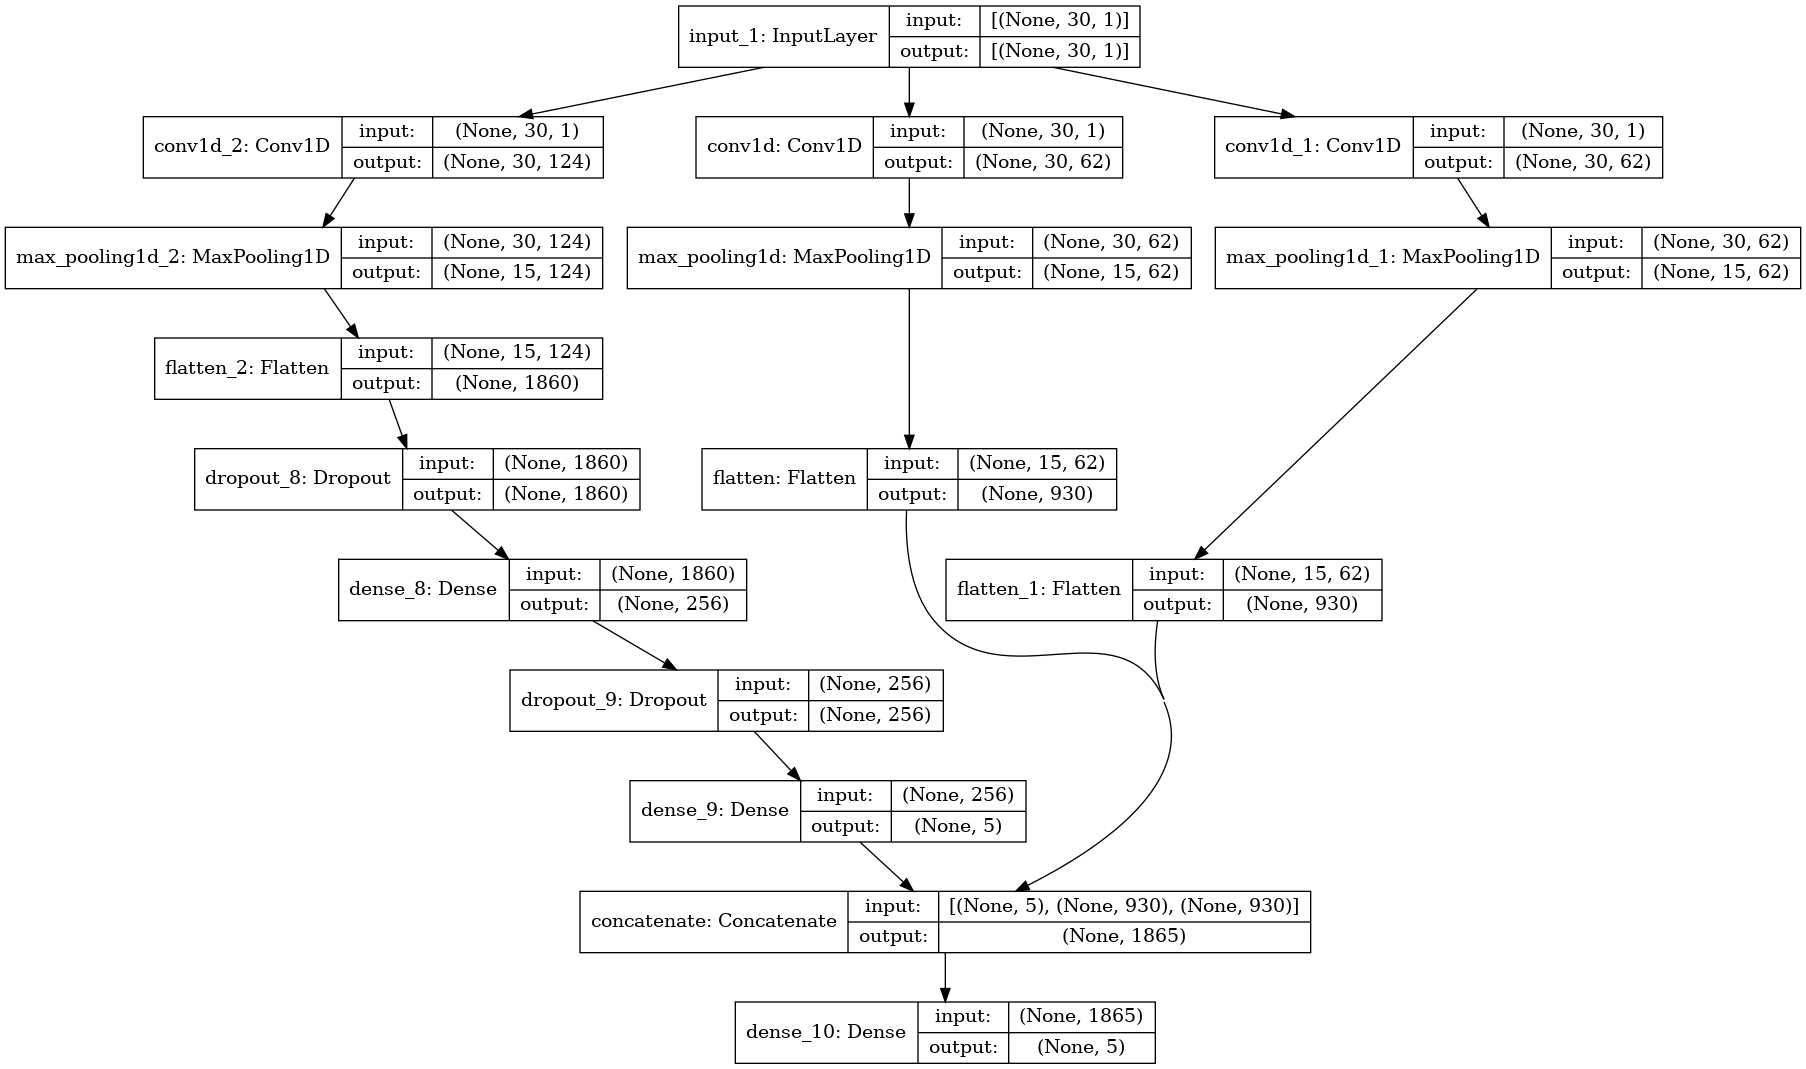

In [36]:
tf.keras.utils.plot_model(cnn_model, to_file="cnn_model.png", show_shapes=True)

In [37]:
cnn_model.fit(X_train.reshape((-1,30,1)), Y_train.values.ravel(), epochs=10, batch_size=32)

Epoch 1/10
10344/10344 [==============================] - 97s 9ms/step - loss: 0.0253 - accuracy: 0.9933
Epoch 2/10
10344/10344 [==============================] - 101s 10ms/step - loss: 0.0091 - accuracy: 0.9976
Epoch 3/10
10344/10344 [==============================] - 111s 11ms/step - loss: 0.0079 - accuracy: 0.9979
Epoch 4/10
10344/10344 [==============================] - 102s 10ms/step - loss: 0.0070 - accuracy: 0.9981
Epoch 5/10
10344/10344 [==============================] - 105s 10ms/step - loss: 0.0066 - accuracy: 0.9983
Epoch 6/10
10344/10344 [==============================] - 105s 10ms/step - loss: 0.0061 - accuracy: 0.9985
Epoch 7/10
10344/10344 [==============================] - 100s 10ms/step - loss: 0.0057 - accuracy: 0.9985
Epoch 8/10
10344/10344 [==============================] - 104s 10ms/step - loss: 0.0054 - accuracy: 0.9986
Epoch 9/10
10344/10344 [==============================] - 103s 10ms/step - loss: 0.0052 - accuracy: 0.9987
Epoch 10/10
10344/10344 [==============

# Testing the neural network

In [38]:
shallow_preds_train = shallow_model.predict(X_train)
shallow_test = shallow_model.predict(X_test)

In [39]:
deep_preds_train = deep_model.predict(X_train)
deep_test = deep_model.predict(X_test)

In [40]:
cnn_preds_train = cnn_model.predict(X_train.reshape((-1,30,1)))
cnn_test = cnn_model.predict(X_test.reshape((-1,30,1)))

In [41]:
print("SHALLOW NEURAL NETWORK")
print("Training Accuracy:", accuracy_score(Y_train, np.argmax(shallow_preds_train, axis=1)))
print("Testing Accuracy:", accuracy_score(Y_test, np.argmax(shallow_test, axis=1)))

SHALLOW NEURAL NETWORK
Training Accuracy: 0.9991389572016411
Testing Accuracy: 0.9989878977101952


In [42]:
print("DEEP NEURAL NETWORK")
print("Training Accuracy:", accuracy_score(Y_train, np.argmax(deep_preds_train, axis=1)))
print("Testing Accuracy:", accuracy_score(Y_test, np.argmax(deep_test, axis=1)))

DEEP NEURAL NETWORK
Training Accuracy: 0.9990604059288084
Testing Accuracy: 0.9989020223643936


In [43]:
print("CONVOLUTIONAL NEURAL NETWORK")
print("Training Accuracy:", accuracy_score(Y_train, np.argmax(cnn_preds_train, axis=1)))
print("Testing Accuracy:", accuracy_score(Y_test, np.argmax(cnn_test, axis=1)))

CONVOLUTIONAL NEURAL NETWORK
Training Accuracy: 0.9990120666839882
Testing Accuracy: 0.9988590846914929


# More info

In [44]:
df.columns

Index(['duration', 'protocol_type', 'flag', 'src_bytes', 'dst_bytes', 'land',
       'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
       'num_compromised', 'root_shell', 'su_attempted', 'num_file_creations',
       'num_shells', 'num_access_files', 'is_guest_login', 'count',
       'srv_count', 'serror_rate', 'rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_diff_srv_rate',
       'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
       'Attack Type'],
      dtype='object')

![image.png](https://i.ibb.co/QH93r9g/Screenshot-from-2022-11-03-02-32-15.png)

![image.png](https://i.ibb.co/B3J7kSV/Screenshot-from-2022-11-03-02-24-30.png)


Table 4: Summarizes attack types and 4 different categories: (1)DoS (Denial of Service attacks), (2) R2L (Root to Local attacks), (3) U2R (User to Root attack), (4) Probe (Probing attacks).